## preprocessing

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

In [6]:
#### I used stratified splitting to preserve class distribution.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   # for imbalance
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227845, 30)
Test shape: (56962, 30)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train[['Amount','Time']] = scaler.fit_transform(X_train[['Amount','Time']])

# Apply same transformation to test
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']])

In [8]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [10]:
print(X_train_res.shape)
print(y_train_res.shape)

(454902, 30)
(454902,)


## modeling and evaluation

In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698631105509169


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9761678060363144


In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.002,  # approx fraud %
    random_state=42
)

iso.fit(X_train[y_train == 0])

,n_estimators,100
,max_samples,'auto'
,contamination,0.002
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [15]:
iso_pred = iso.predict(X_test)

# Convert: -1 → fraud (1), 1 → normal (0)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

print("Isolation Forest:\n")
print(classification_report(y_test, iso_pred))

Isolation Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.22      0.35      0.27        98

    accuracy                           1.00     56962
   macro avg       0.61      0.67      0.63     56962
weighted avg       1.00      1.00      1.00     56962



In [16]:
pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 MB 2.8 MB/s  0:07:14 eta 0:00:010:00:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 3.0 MB/s  0:00:03a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.8 MB/s  0:00:00m 2.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 2.0 MB/s  0:00:00m 4.2 MB/s eta 0:00:01
Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl (429 kB)
Using cached astu

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(optimizer='adam', loss='mse')

In [18]:
autoencoder.fit(
    X_train[y_train == 0],
    X_train[y_train == 0],
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_split=0.1
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - loss: 0.6581 - val_loss: 0.4525
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - loss: 0.4221 - val_loss: 0.3835
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 0.3741 - val_loss: 0.3527
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.3522 - val_loss: 0.3378
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.3404 - val_loss: 0.3299
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - loss: 0.3336 - val_loss: 0.3248
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - loss: 0.3288 - val_loss: 0.3193
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - loss: 0.3211 - val_loss: 0.3095
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - loss: 0.3105 - val_loss: 0.3005
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.3045 - val_loss: 0.2962
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.3011 - val_loss: 0.2937
Epoch 12/20
800/800 ━━━━━━━━━━

In [19]:
import numpy as np

# Reconstruction error on TRAIN (for threshold)
train_recon = autoencoder.predict(X_train[y_train == 0])
train_mse = np.mean(np.power(X_train[y_train == 0] - train_recon, 2), axis=1)

threshold = np.percentile(train_mse, 95)

# Test prediction
test_recon = autoencoder.predict(X_test)
test_mse = np.mean(np.power(X_test - test_recon, 2), axis=1)

ae_pred = [1 if x > threshold else 0 for x in test_mse]

print("Autoencoder:\n")
print(classification_report(y_test, ae_pred))

7108/7108 ━━━━━━━━━━━━━━━━━━━━ 2s 208us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 219us/step
Autoencoder:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.87      0.05        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.51     56962
weighted avg       1.00      0.95      0.97     56962



In [20]:
models = {
    "Logistic Regression": roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
    "Random Forest": roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
}

print(models)

{'Logistic Regression': 0.9698631105509169, 'Random Forest': 0.9761678060363144}


## FRAUD RISK SCORING + THRESHOLD TUNING

In [21]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

configs = [
    {"contamination": 0.001, "n_estimators": 100},
    {"contamination": 0.002, "n_estimators": 200},
    {"contamination": 0.005, "n_estimators": 300},
    {"contamination": 0.01,  "n_estimators": 300},
]

for cfg in configs:
    iso = IsolationForest(
        contamination=cfg["contamination"],
        n_estimators=cfg["n_estimators"],
        random_state=42,
        n_jobs=-1
    )
    
    iso.fit(X_train[y_train == 0])
    
    pred = iso.predict(X_test)
    pred = [1 if x == -1 else 0 for x in pred]
    
    print(f"\nConfig: {cfg}")
    print(classification_report(y_test, pred))


Config: {'contamination': 0.001, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.29      0.30      0.29        98

    accuracy                           1.00     56962
   macro avg       0.65      0.65      0.65     56962
weighted avg       1.00      1.00      1.00     56962


Config: {'contamination': 0.002, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.20      0.29      0.23        98

    accuracy                           1.00     56962
   macro avg       0.60      0.64      0.62     56962
weighted avg       1.00      1.00      1.00     56962


Config: {'contamination': 0.005, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.12      0.40      0.19        98

    accuracy     

#### THRESHOLD TUNING (RANDOM FOREST)

In [22]:
rf_probs = rf.predict_proba(X_test)[:,1]

In [23]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = np.arange(0.1, 0.9, 0.1)

results = []

for t in thresholds:
    preds = (rf_probs > t).astype(int)
    
    print(f"\n🔹 Threshold: {t}")
    print(classification_report(y_test, preds))


🔹 Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.90      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.95      0.74     56962
weighted avg       1.00      1.00      1.00     56962


🔹 Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.90      0.76        98

    accuracy                           1.00     56962
   macro avg       0.83      0.95      0.88     56962
weighted avg       1.00      1.00      1.00     56962


🔹 Threshold: 0.30000000000000004
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.90      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.95      0.91     56962
weig

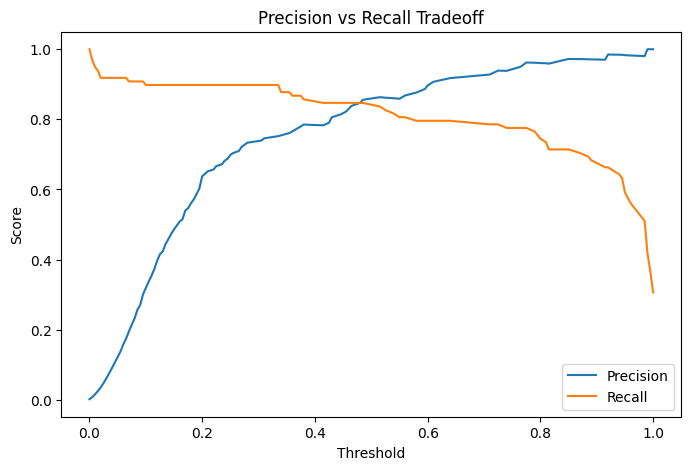

In [24]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision vs Recall Tradeoff")
plt.show()

In [25]:
## best threshold for random forest
best_threshold = 0.3

final_preds = (rf_probs > best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.90      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.95      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
def risk_level(prob):
    if prob > 0.8:
        return "🚨 HIGH RISK"
    elif prob > 0.3:
        return "⚠️ MEDIUM RISK"
    else:
        return "SAFE"

In [27]:
output_df = pd.DataFrame({
    "Fraud Probability": rf_probs,
    "Risk Level": [risk_level(p) for p in rf_probs]
})

output_df.head()

,Fraud Probability,Risk Level
0,0.00,SAFE
1,0.00,SAFE
2,0.02,SAFE
3,0.00,SAFE
4,0.00,SAFE
